In [1]:
import pandas as pd
data=pd.read_csv(r"C:\Users\pragy\OneDrive\Desktop\1M\data_py\fia_py\SAML-D.csv\SAML-D.csv")

In [2]:
data=data[:1000000]

<Axes: ylabel='Amount'>

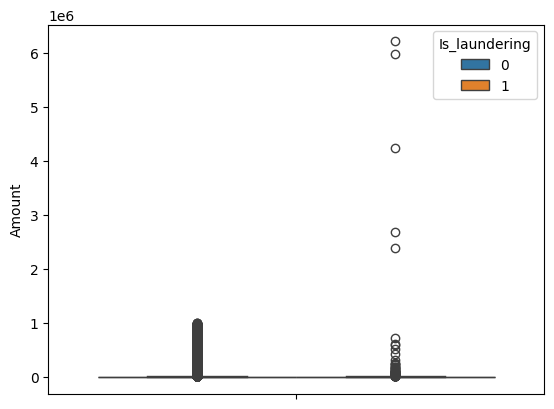

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.boxplot(y='Amount',hue="Is_laundering",data=data)

In [4]:
data.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


<Axes: title={'center': 'Distribution of laundering transactions by currency'}, xlabel='Payment_currency'>

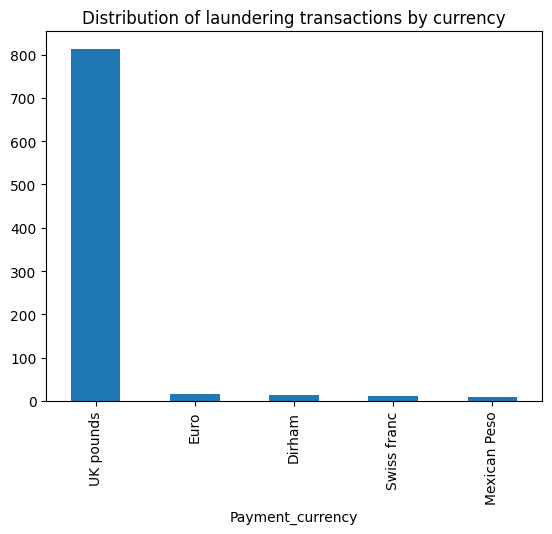

In [26]:
data[data['Is_laundering'] == 1]['Payment_currency'].value_counts().head(5).plot(kind='bar',title="Distribution of laundering transactions by currency")

<Axes: title={'center': 'Top 10 Received_currency with Is_laundering'}, xlabel='Received_currency,Is_laundering'>

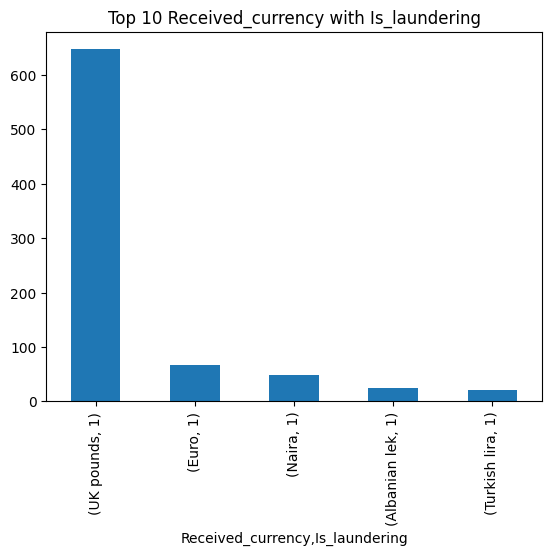

In [ ]:
data[data['Is_laundering'] == 1].groupby('Received_currency')['Is_laundering'].value_counts().sort_values(ascending=False).head(5).plot(kind='bar',title="Top 5 Received_currency with Is_laundering") 

<Axes: title={'center': 'Top 10 Laundering_type with Is_laundering'}, xlabel='Laundering_type,Is_laundering'>

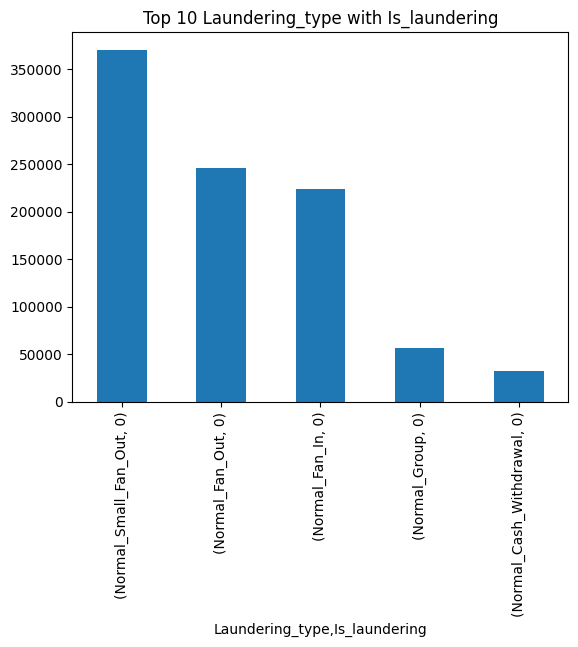

In [ ]:
data.groupby('Laundering_type')['Is_laundering'].value_counts().sort_values(ascending=False).head(5).plot(kind='bar',title="Top 5 Laundering_type with Is_laundering")

In [8]:
print(data['Sender_account'][data['Is_laundering'] == 1].value_counts().head(5))

Sender_account
6770601554    13
3651814546    13
9586816158    10
1600149721     9
9678311627     9
Name: count, dtype: int64


In [9]:
data['date_col']=pd.to_datetime(data['Date'])
data.head(5)
year=data['date_col'].dt.year
month=data['date_col'].dt.month
day=data['date_col'].dt.day
print(f'Year: {year}, Month: {month}, Day: {day}')

Year: 0         2022
1         2022
2         2022
3         2022
4         2022
          ... 
999995    2022
999996    2022
999997    2022
999998    2022
999999    2022
Name: date_col, Length: 1000000, dtype: int32, Month: 0         10
1         10
2         10
3         10
4         10
          ..
999995    11
999996    11
999997    11
999998    11
999999    11
Name: date_col, Length: 1000000, dtype: int32, Day: 0          7
1          7
2          7
3          7
4          7
          ..
999995    10
999996    10
999997    10
999998    10
999999    10
Name: date_col, Length: 1000000, dtype: int32


In [10]:
# print(day.value_counts())
weekday=data['date_col'].dt.weekday
week=weekday.replace({0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}).value_counts()
print(week)

date_col
Tuesday      151213
Monday       146344
Saturday     146195
Wednesday    144771
Sunday       137980
Thursday     137248
Friday       136249
Name: count, dtype: int64


<Axes: xlabel='date_col'>

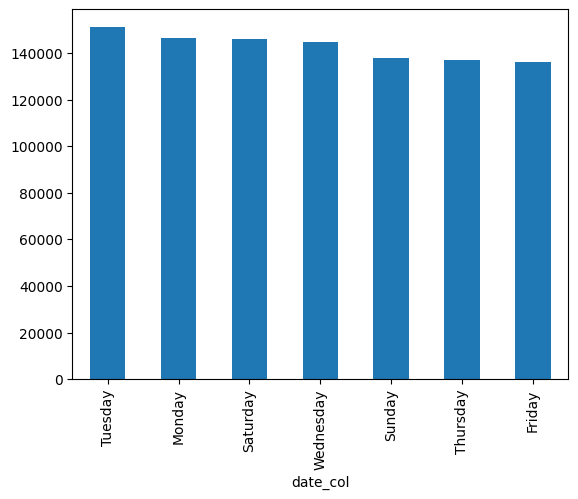

In [11]:
week.plot(kind='bar')

<Axes: xlabel='date_col'>

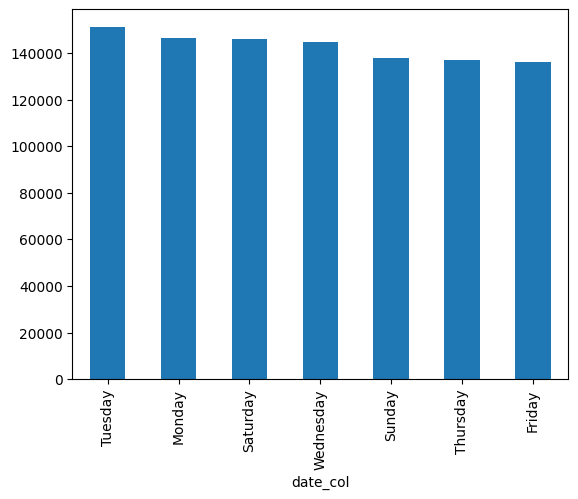

In [12]:
week.plot(kind='bar')

In [28]:
data['Time_col']=pd.to_datetime(data['Time'])
hour=data['Time_col'].dt.hour
print(hour.value_counts())


C:\Users\pragy\AppData\Local\Temp\ipykernel_4448\3265190259.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Time_col']=pd.to_datetime(data['Time'])


Time_col
11    58183
15    57924
13    57816
12    57738
14    57668
16    57586
10    56869
8     56403
17    56250
9     56167
22    54413
23    54149
20    54140
19    53899
21    53777
18    53694
7     15031
3     12773
1     12724
0     12680
4     12665
2     12542
5     12493
6     12416
Name: count, dtype: int64


In [30]:
hour.value_counts()

Time_col
11    58183
15    57924
13    57816
12    57738
14    57668
16    57586
10    56869
8     56403
17    56250
9     56167
22    54413
23    54149
20    54140
19    53899
21    53777
18    53694
7     15031
3     12773
1     12724
0     12680
4     12665
2     12542
5     12493
6     12416
Name: count, dtype: int64

<Axes: title={'center': 'Distribution of transactions by hour of the day'}, xlabel='Time_col'>

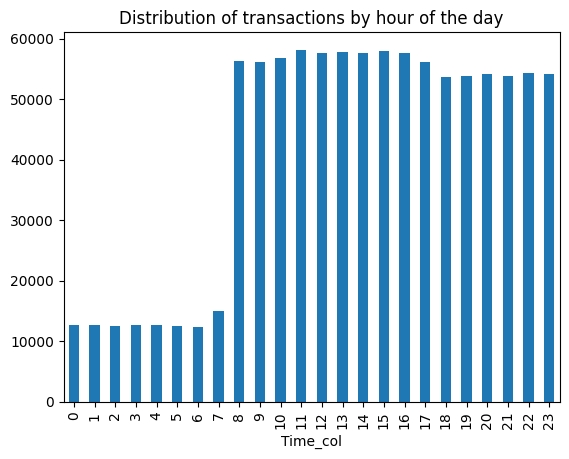

In [ ]:

hours=hour.value_counts().sort_index()

hours.plot(kind='bar',title="Distribution of transactions by hour of the day")

<Axes: title={'center': 'Top 10 Payment_type with Is_laundering'}, xlabel='Payment_type'>

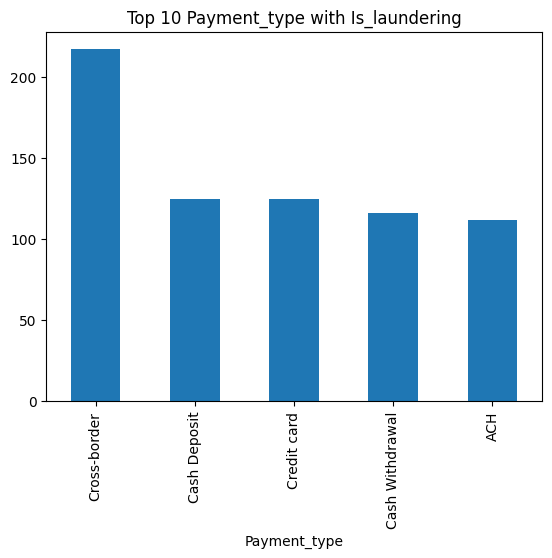

In [31]:
data[data['Is_laundering']==1]["Payment_type"].value_counts().head(5).plot(kind='bar',title="Top 10 Payment_type with Is_laundering")

In [32]:
data['Payment_type'].value_counts()

Payment_type
ACH                212212
Credit card        211867
Cheque             211682
Debit card         211402
Cross-border        96873
Cash Withdrawal     31956
Cash Deposit        24008
Name: count, dtype: int64